In [31]:
import Kea
from Kea.utils import plotting, data_reader
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

from Kea.api.sim_data import SimulationData, SimulationType

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

from scipy import fft

import emcee

L = 2.*np.pi
D = 3
d = D - 1
phys_dims = [L for _ in range(D)]

In [32]:
data = SimulationData(SimulationType.H5_SEAN, '/home/m/Documents/science_codes/Data/cmhd3d/', ['rho'], '04', phys_dims=phys_dims)
_ = data.dephase_data(['rho'])

_ = data.project('rho', axis=2)
_ = data.dephase_data('x3proj_rho')

Reading file: z3-mhd3-04-uno-Xsp-rho.h5
Loaded rho
Created rho_dephase
Created x3proj_rho
Created x3proj_rho_dephase


In [33]:
rho_spec = data.spectrum('rho')
_, _ = rho_spec.integrate()

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


In [34]:
xx = rho_spec.modal_k
yy = rho_spec.modal_fek
yy = yy/L**D
yyerr = np.ones_like(yy)

In [35]:
## Fit to spectra, generate fBm field with same parameters
def exp_powerlaw(xx, a1, a2, a3, a4, bb, b1, b2, delta):
    pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
    # Set where it is not defined to 0
    pl[~np.isfinite(pl)] = 0.
    # Outside the axis to be 0
    minn = np.where(xx == np.nanmin(xx))
    idx = [m for m in minn]
    idx[0] = slice(0,np.max(xx.shape))
    idx = tuple(idx)
    maxx = np.max(xx[idx])
    pl[xx > maxx] = 0.
    pl = 1e-3*pl/pl[1]
    return pl

In [36]:
def log_likelihood(theta, x, y, yerr):
    model = exp_powerlaw(x, *theta)
    sigma2 = model**2
    return -0.5 * np.nansum((y - model)**2 / sigma2)

def log_prior(theta):
    a1, a2, a3, a4, bb, b1, b2, delta = theta
    if a1 < 1. or a1 > 10.:
        return -np.inf
    if a2 < 1. or a2 > 10.:
        return -np.inf
    if a3 < 1. or a3 > 10.:
        return -np.inf
    if a4 < 1. or a4 > 10.:
        return -np.inf
    if bb > 512 or bb < 0.:
        return -np.inf
    if b1 > 512 or b1 < 0.:
        return -np.inf
    if b2 > 512 or b2 < 0.:
        return -np.inf 
    if delta < 0. or delta > 2.:
        return -np.inf
    return 0.0

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [37]:
from scipy.optimize import minimize

nll = lambda *args: -log_likelihood(*args)
initial = [2.26982873, 6.49604408e-01, 2.93173100e+01, 7.83533183e+00, 1.09963580e+07, 1.52568248e+00, 9.20105996e+00, 1.00000193e+00]
soln = minimize(nll, initial, args=(xx, yy, yyerr))
print(soln.x)

[2.26982873e+00 6.49604408e-01 2.93173100e+01 7.83533183e+00
 1.09963580e+07 1.52568248e+00 9.20105996e+00 1.00000193e+00]


/tmp/ipykernel_91115/1919248584.py:4: RuntimeWarning: divide by zero encountered in true_divide
  return -0.5 * np.nansum((y - model)**2 / sigma2)
/home/m/.local/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [38]:
pos = soln.x + 1e-4 * np.random.randn(32, len(soln.x))
nwalkers, ndim = 32, len(soln.x)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(xx, yy, yyerr))
sampler.run_mcmc(pos, 5000, progress=True)

  0%|          | 0/5000 [00:00<?, ?it/s]/home/m/.local/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:02<00:00, 2257.00it/s]


State([[2.26977383e+00 6.49633643e-01 2.93171356e+01 7.83521166e+00
  1.09963580e+07 1.52564884e+00 9.20098039e+00 1.00011227e+00]
 [2.26993987e+00 6.49747083e-01 2.93173529e+01 7.83534654e+00
  1.09963580e+07 1.52559423e+00 9.20104077e+00 9.99947004e-01]
 [2.26987301e+00 6.49534279e-01 2.93172390e+01 7.83546657e+00
  1.09963580e+07 1.52582969e+00 9.20103328e+00 9.99916742e-01]
 [2.26980729e+00 6.49786911e-01 2.93173203e+01 7.83549883e+00
  1.09963580e+07 1.52572733e+00 9.20126178e+00 1.00007900e+00]
 [2.26978680e+00 6.49590456e-01 2.93174311e+01 7.83540374e+00
  1.09963580e+07 1.52554712e+00 9.20112150e+00 9.99780348e-01]
 [2.26981830e+00 6.49694394e-01 2.93174056e+01 7.83526256e+00
  1.09963580e+07 1.52571170e+00 9.20107870e+00 1.00004466e+00]
 [2.26985334e+00 6.49549784e-01 2.93172761e+01 7.83545031e+00
  1.09963580e+07 1.52585142e+00 9.20089231e+00 9.99895863e-01]
 [2.27001384e+00 6.49639828e-01 2.93170909e+01 7.83532296e+00
  1.09963580e+07 1.52582844e+00 9.20106592e+00 9.99983229

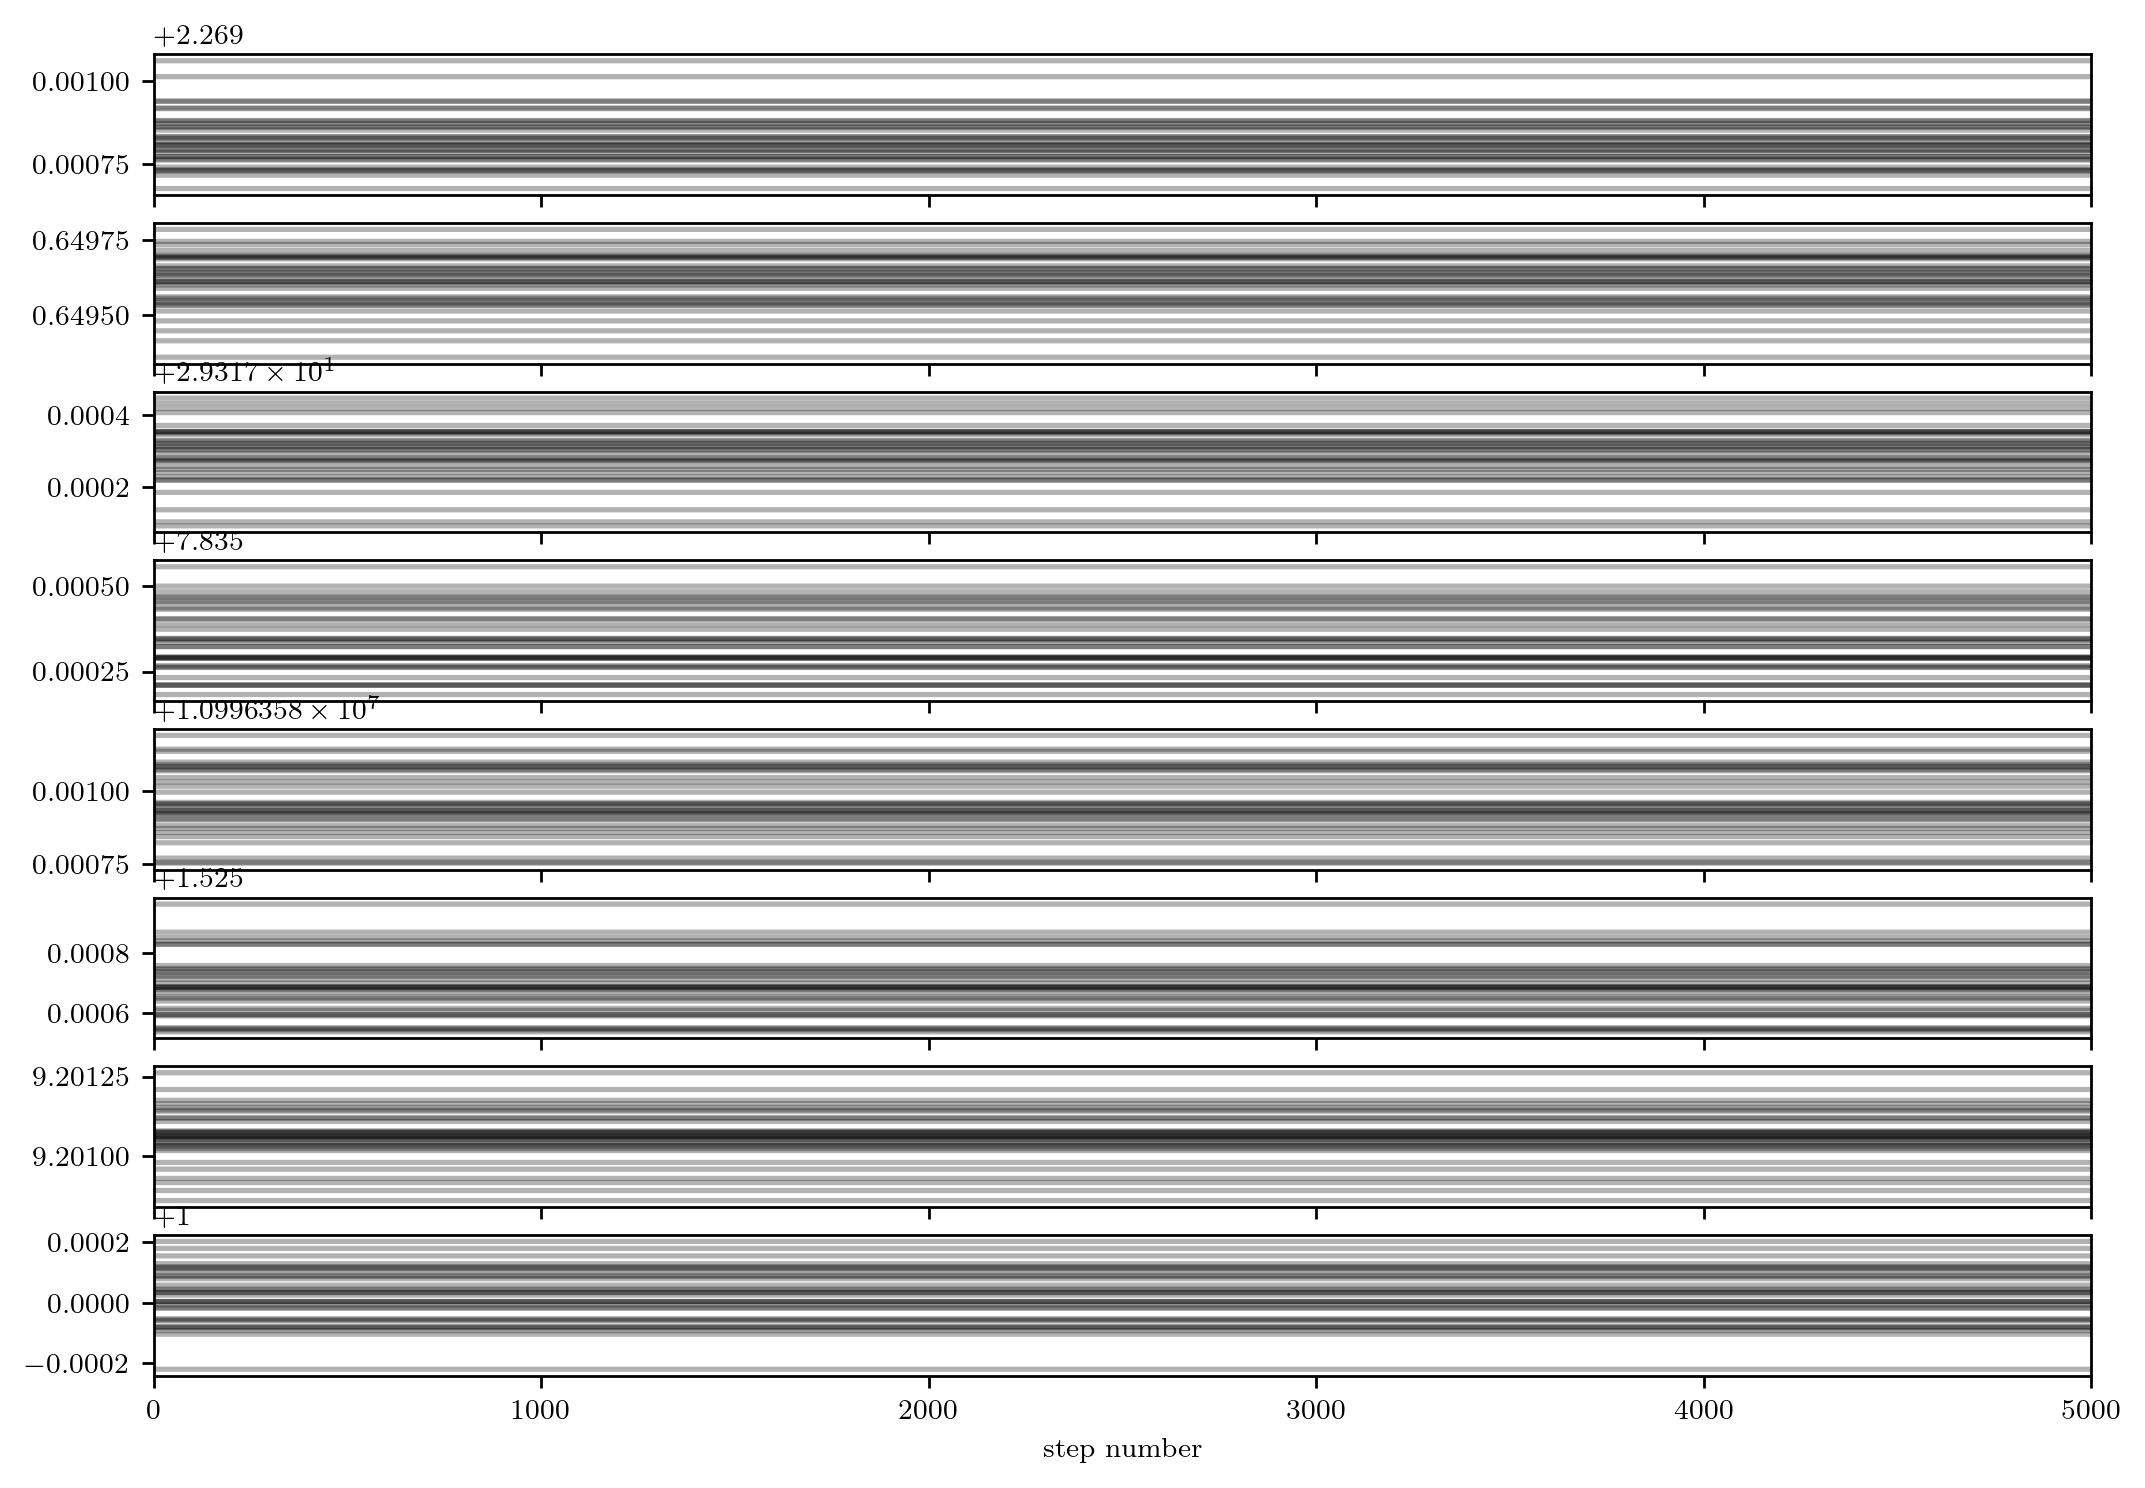

In [40]:
fig, axes = plt.subplots(len(soln.x), figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

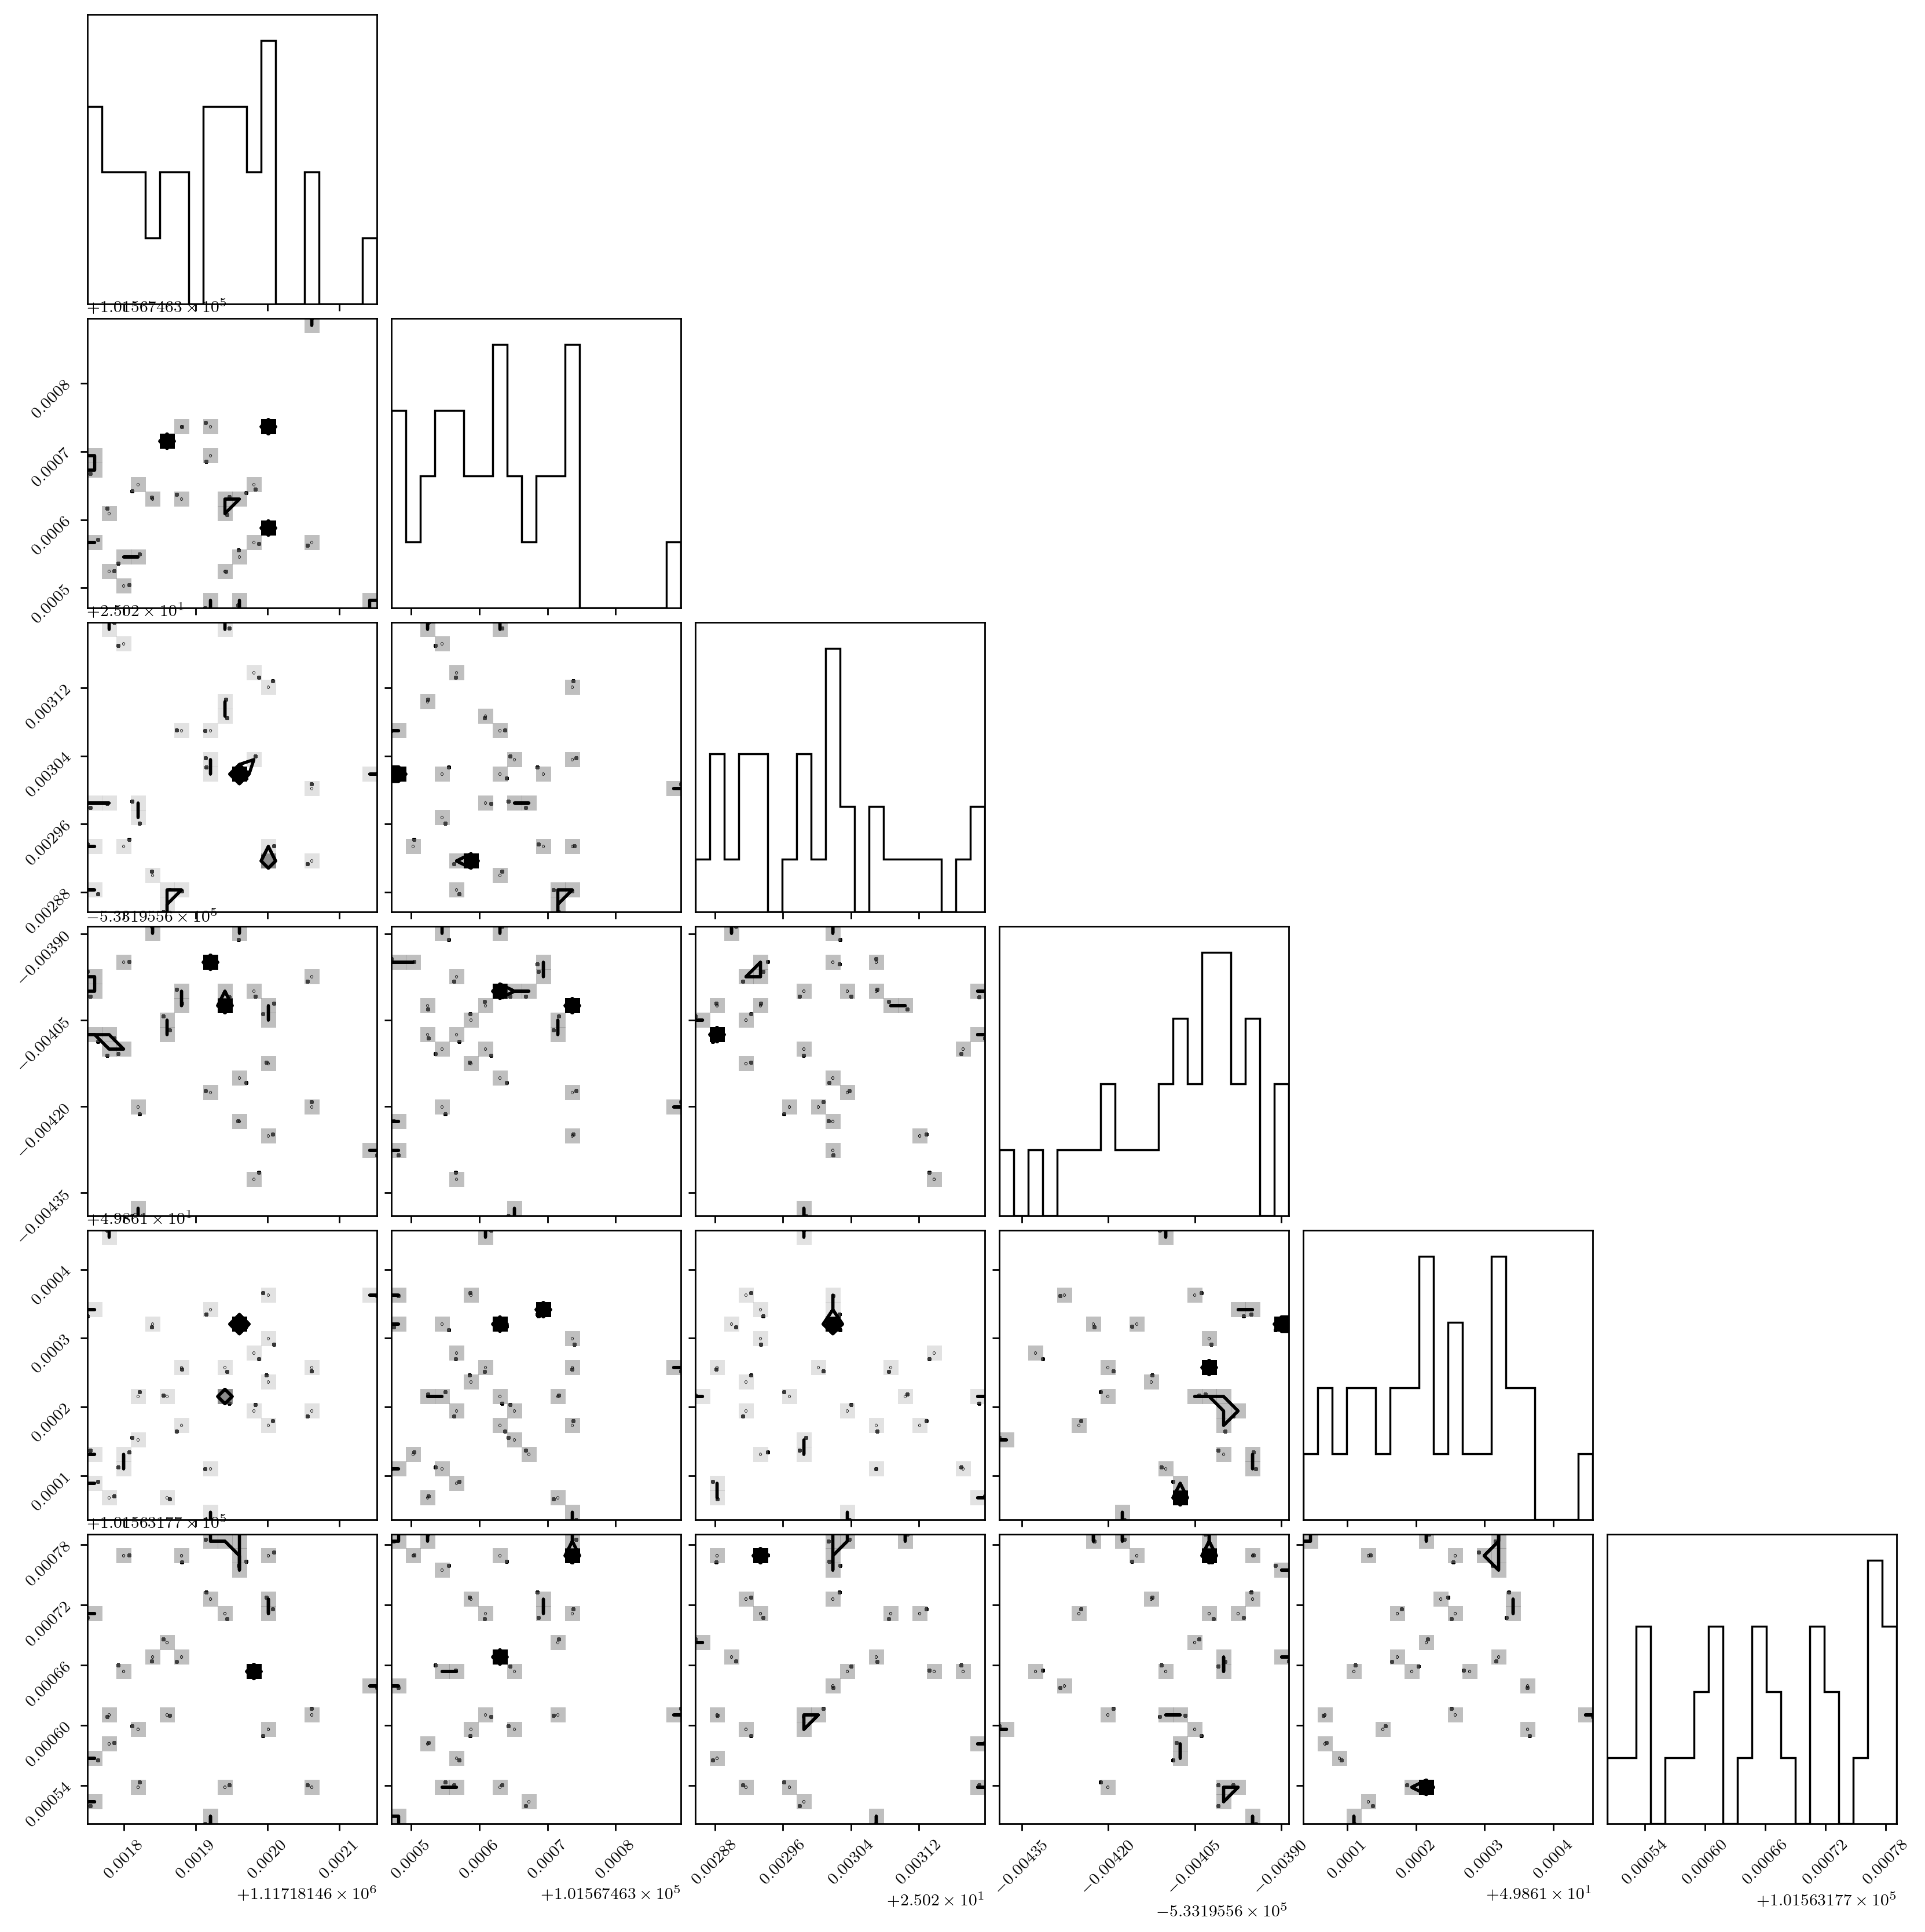

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

fig = corner.corner(flat_samples)